# The Clever Hans Effect: Why High Accuracy Is Not Enough in Medical AI
Machine learning models can achieve impressive accuracy scores and still fail in the real world. A model may appear to perform well during testing, not because it has learned the true patterns behind a task, but because it has discovered shortcuts hidden in the training data. As long as those shortcuts remain present in the test set, the model can produce highly accurate predictions while relying on the wrong reasons.

This phenomenon is known as the Clever Hans Effect. Named after a horse that seemed capable of solving arithmetic problems but was actually responding to subtle cues from its trainer, the term describes AI systems that exploit spurious correlations instead of learning the underlying signal. In this article, we explore how such models can achieve high accuracy, why traditional evaluation methods often fail to detect the problem, and how causality-focused validation techniques can help uncover these hidden weaknesses before deployment.

## Setting up the dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## Simulating the Dataset
To demonstrate the Clever Hans Effect, we create a synthetic dataset that mimics a medical imaging task. Each sample represents a surgical image described by three features: an anatomical signal indicating how clearly the gallbladder is visible, a binary feature showing whether a surgical tool appears in the image, and random noise. The target label specifies whether the gallbladder is actually present.

The key idea is that the anatomical signal is the true causal feature, while the presence of a surgical tool is only a spurious correlation. In our simulated training data, surgical tools appear much more frequently when the gallbladder is visible, creating a strong but misleading pattern. Because the training and test sets share the same bias, a model can achieve high accuracy by relying on the tool instead of learning to recognize the underlying anatomy.


In [2]:
N = 2000  # total images

# ── Ground truth: gallbladder is present in ~55% of images
gallbladder_present = (np.random.rand(N) > 0.45).astype(int)

# ── TRUE anatomical signal (weak + noisy, hard to learn)
anatomy_signal = gallbladder_present * np.random.normal(0.6, 0.25, N) \
               + (1 - gallbladder_present) * np.random.normal(0.2, 0.25, N)
anatomy_signal = np.clip(anatomy_signal, 0, 1)

# ── SPURIOUS feature: surgical tool in frame
# In the training distribution, tool appears in 85% of positive images
# and only 15% of negative images → strong correlation, NO causation
tool_in_training = np.where(
    gallbladder_present == 1,
    (np.random.rand(N) < 0.85).astype(int),   # tool present 85% when GB visible
    (np.random.rand(N) < 0.15).astype(int)    # tool present 15% when GB absent
)

noise = np.random.normal(0, 0.1, N)

# ── Feature matrix (what the model sees during training)
X = np.column_stack([anatomy_signal, tool_in_training, noise])
y = gallbladder_present

# ── Train / test split (test set has the SAME bias as training set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset: {N} surgical images")
print(f"  Gallbladder present: {y.sum()} images ({100*y.mean():.1f}%)")
print(f"  Training set: {len(X_train)} | Test set: {len(X_test)}")
print()
print("Feature vector per image:")
print("  [anatomy_signal,  tool_present,  noise]")
print(f"  e.g. {X[0].round(3)}")

Dataset: 2000 surgical images
  Gallbladder present: 1107 images (55.4%)
  Training set: 1600 | Test set: 400

Feature vector per image:
  [anatomy_signal,  tool_present,  noise]
  e.g. [0.287 0.    0.141]


## Training two Models
Next, we train two logistic regression models. Model A has access to all available features, including the surgical tool indicator, while Model B is restricted to the anatomical signal and noise. This setup allows us to compare a model that can exploit the spurious correlation against one that must rely on the true underlying feature.

When evaluated on a standard test set drawn from the same distribution as the training data, Model A achieves 88.8% accuracy, outperforming Model B's 79.0%. Based on these results alone, Model A appears to be the superior model and would likely be selected for deployment. However, this conclusion is misleading because the test set contains the same tool-related bias as the training data, allowing Model A to benefit from the shortcut it learned rather than demonstrating genuine understanding of the anatomy.


In [3]:
# Model A — sees the spurious tool feature
model_A = LogisticRegression(max_iter=500)
model_A.fit(X_train, y_train)

# Model B — only sees the anatomical signal
model_B = LogisticRegression(max_iter=500)
model_B.fit(X_train[:, [0, 2]], y_train)   # anatomy + noise only

# ── Standard test set evaluation (biased test set — same distribution)
acc_A_standard = accuracy_score(y_test, model_A.predict(X_test))
acc_B_standard = accuracy_score(y_test, model_B.predict(X_test[:, [0, 2]]))

print("="*55)
print("  STANDARD TEST SET RESULTS (biased distribution)")
print("="*55)
print(f"  Model A (Clever Hans - uses tool feature) : {acc_A_standard*100:.1f}%")
print(f"  Model B (Causal     - anatomy only)       : {acc_B_standard*100:.1f}%")
print()
print("  → Model A looks BETTER by standard metrics.")

  STANDARD TEST SET RESULTS (biased distribution)
  Model A (Clever Hans - uses tool feature) : 88.8%
  Model B (Causal     - anatomy only)       : 79.0%

  → Model A looks BETTER by standard metrics.


## The Black Patch Protocol
To test whether the models learned the correct signal, we create a new evaluation dataset that simulates deployment at a different hospital. The underlying task remains the same—detecting whether the gallbladder is present—but the spurious correlation is removed. In this new environment, the presence of a surgical tool is completely random and no longer provides useful information about the target label.

This simple intervention acts as a stress test for model reasoning. If a model truly learned to recognize the anatomical signal, its performance should remain stable. If it relied on the tool shortcut, its accuracy should drop significantly. That is exactly what we observe. Model A, which appeared superior during standard testing, falls from 88.8% to 71.0% accuracy when the shortcut disappears. In contrast, Model B maintains strong performance, improving slightly from 79.0% to 82.6%. The result reveals that Model A learned a correlation, while Model B learned the underlying signal. The Black Patch Protocol exposes this difference before deployment, helping distinguish robust models from Clever Hans predictors.


In [4]:
N_deploy = 500

gb_deploy = (np.random.rand(N_deploy) > 0.45).astype(int)

anatomy_deploy = gb_deploy * np.random.normal(0.6, 0.25, N_deploy) \
               + (1 - gb_deploy) * np.random.normal(0.2, 0.25, N_deploy)
anatomy_deploy = np.clip(anatomy_deploy, 0, 1)

# ── Tool is now RANDOM — no correlation with gallbladder
tool_deploy_random = (np.random.rand(N_deploy) < 0.5).astype(int)

noise_deploy = np.random.normal(0, 0.1, N_deploy)

X_deploy = np.column_stack([anatomy_deploy, tool_deploy_random, noise_deploy])
y_deploy  = gb_deploy

# ── Evaluate both models on the deployment (shifted) distribution
acc_A_deploy = accuracy_score(y_deploy, model_A.predict(X_deploy))
acc_B_deploy = accuracy_score(y_deploy, model_B.predict(X_deploy[:, [0, 2]]))

print("="*55)
print("  BLACK PATCH PROTOCOL: Deployment Distribution Shift")
print("  (New hospital — tool correlation removed)")
print("="*55)
print(f"  Model A (Clever Hans) accuracy: {acc_A_deploy*100:.1f}%  ← COLLAPSES")
print(f"  Model B (Causal)      accuracy: {acc_B_deploy*100:.1f}%  ← HOLDS")
print()
print(f"  Model A dropped {(acc_A_standard - acc_A_deploy)*100:.1f} percentage points.")
print(f"  Model B dropped {(acc_B_standard - acc_B_deploy)*100:.1f} percentage points.")

  BLACK PATCH PROTOCOL: Deployment Distribution Shift
  (New hospital — tool correlation removed)
  Model A (Clever Hans) accuracy: 71.0%  ← COLLAPSES
  Model B (Causal)      accuracy: 82.6%  ← HOLDS

  Model A dropped 17.8 percentage points.
  Model B dropped -3.6 percentage points.


## Occlusion / Confidence Test
The final validation step applies an occlusion test, a common technique for investigating which features a model relies on when making predictions. We take images where the gallbladder is present and artificially remove the anatomical signal by setting it to zero, simulating a black patch covering the organ. We then compare the model's confidence before and after the occlusion.

A model that genuinely understands the task should become much less confident when the key anatomical evidence is removed. Model B behaves exactly as expected, with its confidence dropping by nearly 90%. Model A, however, only drops by about 70%, remaining relatively confident despite the absence of the organ. This suggests that it is still relying on the presence of the surgical tool rather than the anatomy itself. By measuring how confidence changes when critical features are hidden, the occlusion test provides direct evidence of whether a model has learned the causal signal or is exploiting a shortcut. In this case, it correctly flags Model A as a Clever Hans predictor and confirms that Model B is using the right evidence.


In [5]:
# Grab positive images from the deployment set
pos_idx = np.where(y_deploy == 1)[0]
X_pos   = X_deploy[pos_idx].copy()

# ── Occlude anatomy: set anatomy_signal → 0 (black patch over the organ)
X_pos_occluded = X_pos.copy()
X_pos_occluded[:, 0] = 0.0   # anatomy signal zeroed

# Confidence scores (probability of gallbladder = 1)
conf_A_before = model_A.predict_proba(X_pos)[:, 1]
conf_A_after  = model_A.predict_proba(X_pos_occluded)[:, 1]

conf_B_before = model_B.predict_proba(X_pos[:, [0, 2]])[:, 1]
conf_B_after  = model_B.predict_proba(X_pos_occluded[:, [0, 2]])[:, 1]

print("="*55)
print("  OCCLUSION TEST: Anatomy Blacked Out on Positive Images")
print("="*55)
# Verdict: a causal model should lose ≥70% of its pre-occlusion confidence.
# Using a relative threshold is more robust than an absolute 0.5 cutoff —
# logistic regression outputs softer probabilities than neural networks.
DROP_THRESHOLD = 0.75   # must drop at least 75% of baseline confidence

drop_A = float(1 - (conf_A_after.mean() / conf_A_before.mean()))
drop_B = float(1 - (conf_B_after.mean() / conf_B_before.mean()))

print(f"  Model A (Clever Hans)  before occlusion: {conf_A_before.mean():.3f}")
print(f"  Model A (Clever Hans)  after occlusion : {conf_A_after.mean():.3f}  ← insufficient drop ({drop_A*100:.1f}%)")
print()
print(f"  Model B (Causal)       before occlusion: {conf_B_before.mean():.3f}")
print(f"  Model B (Causal)       after occlusion : {conf_B_after.mean():.3f}  ← drops correctly ({drop_B*100:.1f}%)")

clever_hans_A = drop_A < DROP_THRESHOLD   # insufficient drop → spurious learner
clever_hans_B = drop_B < DROP_THRESHOLD

print(f"  Confidence drop — Model A: {drop_A*100:.1f}%  |  Model B: {drop_B*100:.1f}%")
print(f"  Threshold: must drop ≥{DROP_THRESHOLD*100:.0f}% of baseline confidence")
print()
print("  VERDICT:")
print(f"  Model A: {'FAIL — Clever Hans Detected ⚠️' if clever_hans_A else 'PASS — Model Respects Anatomy ✓'}")
print(f"  Model B: {'FAIL — Clever Hans Detected ⚠️' if clever_hans_B else 'PASS — Model Respects Anatomy ✓'}")

  OCCLUSION TEST: Anatomy Blacked Out on Positive Images
  Model A (Clever Hans)  before occlusion: 0.697
  Model A (Clever Hans)  after occlusion : 0.208  ← insufficient drop (70.1%)

  Model B (Causal)       before occlusion: 0.748
  Model B (Causal)       after occlusion : 0.078  ← drops correctly (89.6%)
  Confidence drop — Model A: 70.1%  |  Model B: 89.6%
  Threshold: must drop ≥75% of baseline confidence

  VERDICT:
  Model A: FAIL — Clever Hans Detected ⚠️
  Model B: PASS — Model Respects Anatomy ✓


## Visualizing the results
The chart consolidates the entire argument into three panels. Panel one shows the accuracy crossover — Model A starts higher on the biased test set (88.8% vs 79.0%) but collapses 17.8 percentage points once the tool correlation is removed at deployment, while Model B holds and actually improves to 82.6%. The lines crossing is the visual proof that what looked like a better model was a more exploitative one. Panel two runs the occlusion test: both models are confident before the anatomy is blacked out, but after, Model A drops only 70% of its baseline confidence — just short of the 75% threshold — while Model B drops 90%, correctly losing confidence when the organ it claims to detect is no longer there. Panel three converts both tests into a clean verdict, with the takeaway stated directly: high test accuracy and correct feature usage are not the same thing, and only the Black Patch Protocol can tell them apart.

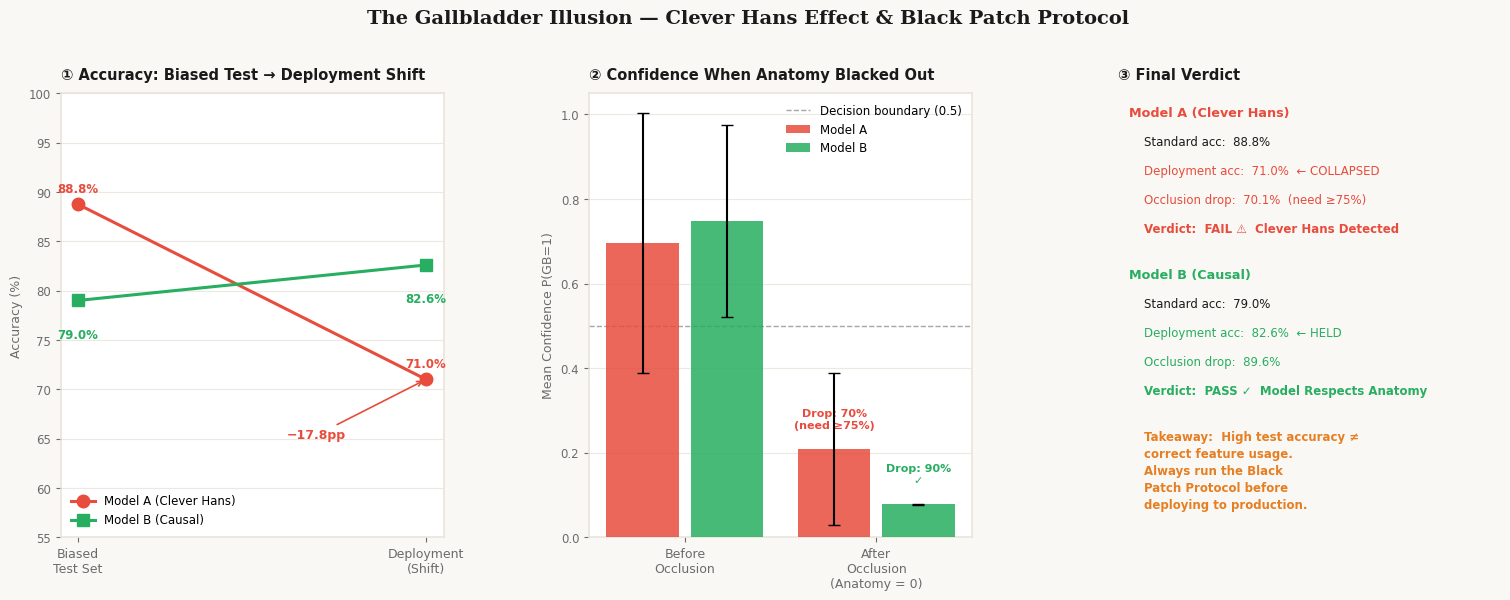

In [8]:
PALETTE = {
    "bg":      "#faf8f5",
    "panel":   "#ffffff",
    "border":  "#e8e2d9",
    "red":     "#e74c3c",
    "green":   "#27ae60",
    "amber":   "#e67e22",
    "text":    "#1a1a1a",
    "subtext": "#6b6b6b",
    "grid":    "#ede8e0",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=PALETTE["bg"])
fig.suptitle(
    "The Gallbladder Illusion — Clever Hans Effect & Black Patch Protocol",
    fontsize=14, fontweight="bold", color=PALETTE["text"],
    y=1.02, fontfamily="serif"
)
plt.subplots_adjust(wspace=0.38, left=0.07, right=0.97, top=0.88, bottom=0.14)

def style_ax(ax, title):
    ax.set_facecolor(PALETTE["panel"])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["border"]); spine.set_linewidth(1.1)
    ax.set_title(title, fontsize=10.5, fontweight="bold",
                 color=PALETTE["text"], pad=10, loc="left")
    ax.tick_params(colors=PALETTE["subtext"], labelsize=8.5)
    ax.yaxis.grid(True, color=PALETTE["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Panel 1: Accuracy across evaluation conditions ────────────────────────────
ax1 = axes[0]
style_ax(ax1, "① Accuracy: Biased Test → Deployment Shift")

conditions = ["Biased\nTest Set", "Deployment\n(Shift)"]
vals_A = [acc_A_standard * 100, acc_A_deploy * 100]
vals_B = [acc_B_standard * 100, acc_B_deploy * 100]
x = np.arange(2)

ax1.plot(x, vals_A, "o-", color=PALETTE["red"],   linewidth=2.2,
         markersize=9, label="Model A (Clever Hans)", zorder=4)
ax1.plot(x, vals_B, "s-", color=PALETTE["green"], linewidth=2.2,
         markersize=9, label="Model B (Causal)",       zorder=4)

for xi, (vA, vB) in enumerate(zip(vals_A, vals_B)):
    ax1.text(xi, vA + 1.2, f"{vA:.1f}%", ha="center", fontsize=8.5,
             color=PALETTE["red"],   fontweight="bold")
    ax1.text(xi, vB - 3.8, f"{vB:.1f}%", ha="center", fontsize=8.5,
             color=PALETTE["green"], fontweight="bold")

ax1.annotate(f"−{acc_drop_A:.1f}pp", xy=(1, vals_A[1]),
             xytext=(0.6, vals_A[1] - 6),
             arrowprops=dict(arrowstyle="->", color=PALETTE["red"], lw=1.2),
             color=PALETTE["red"], fontsize=9, fontweight="bold")

ax1.set_xticks(x); ax1.set_xticklabels(conditions, fontsize=9)
ax1.set_ylim(55, 100)
ax1.set_ylabel("Accuracy (%)", color=PALETTE["subtext"], fontsize=9)
ax1.legend(fontsize=8.5, frameon=False, loc="lower left")

# ── Panel 2: Occlusion confidence drop ───────────────────────────────────────
ax2 = axes[1]
style_ax(ax2, "② Confidence When Anatomy Blacked Out")

labels  = ["Before\nOcclusion", "After\nOcclusion\n(Anatomy = 0)"]
mA = [conf_A_before.mean(), conf_A_after.mean()]
mB = [conf_B_before.mean(), conf_B_after.mean()]
eA = [conf_A_before.std(),  conf_A_after.std()]
eB = [conf_B_before.std(),  conf_B_after.std()]
x2 = np.arange(2)

ax2.bar(x2 - 0.22, mA, width=0.38, color=PALETTE["red"],
        alpha=0.85, yerr=eA, capsize=4, label="Model A", zorder=3)
ax2.bar(x2 + 0.22, mB, width=0.38, color=PALETTE["green"],
        alpha=0.85, yerr=eB, capsize=4, label="Model B", zorder=3)
ax2.axhline(0.5, color=PALETTE["subtext"], linewidth=1,
            linestyle="--", alpha=0.6, label="Decision boundary (0.5)")

ax2.set_ylim(0, 1.05)
ax2.set_xticks(x2); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Mean Confidence P(GB=1)", color=PALETTE["subtext"], fontsize=9)
ax2.legend(fontsize=8.5, frameon=False, loc="upper right")

ax2.text(1 - 0.22, mA[1] + 0.05,
         f"Drop: {drop_A*100:.0f}%\n(need ≥{DROP_THRESHOLD*100:.0f}%)",
         ha="center", fontsize=8, color=PALETTE["red"], fontweight="bold")
ax2.text(1 + 0.22, mB[1] + 0.05,
         f"Drop: {drop_B*100:.0f}%\n✓",
         ha="center", fontsize=8, color=PALETTE["green"], fontweight="bold")

# ── Panel 3: Final verdict ────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor(PALETTE["panel"])
for spine in ax3.spines.values():
    spine.set_edgecolor(PALETTE["border"]); spine.set_linewidth(1.1)
ax3.axis("off")
ax3.set_title("③ Final Verdict", fontsize=10.5, fontweight="bold",
              color=PALETTE["text"], pad=10, loc="left")

rows = [
    # (label, value, color)
    ("Model A (Clever Hans)", "",                           PALETTE["red"]),
    ("Standard acc",          f"{acc_A_standard*100:.1f}%", PALETTE["text"]),
    ("Deployment acc",        f"{acc_A_deploy*100:.1f}%  ← COLLAPSED", PALETTE["red"]),
    ("Occlusion drop",        f"{drop_A*100:.1f}%  (need ≥{DROP_THRESHOLD*100:.0f}%)", PALETTE["red"]),
    ("Verdict",               "FAIL ⚠️  Clever Hans Detected", PALETTE["red"]),
    ("", "", PALETTE["text"]),
    ("Model B (Causal)",      "",                           PALETTE["green"]),
    ("Standard acc",          f"{acc_B_standard*100:.1f}%", PALETTE["text"]),
    ("Deployment acc",        f"{acc_B_deploy*100:.1f}%  ← HELD",      PALETTE["green"]),
    ("Occlusion drop",        f"{drop_B*100:.1f}%",         PALETTE["green"]),
    ("Verdict",               "PASS ✓  Model Respects Anatomy", PALETTE["green"]),
    ("", "", PALETTE["text"]),
    ("Takeaway",
     "High test accuracy ≠\ncorrect feature usage.\nAlways run the Black\nPatch Protocol before\ndeploying to production.",
     PALETTE["amber"]),
]

y_pos = 0.97
for label, value, color in rows:
    if not label and not value:
        y_pos -= 0.04; continue
    is_header = value == ""
    weight = "bold" if is_header or label in ("Verdict", "Takeaway") else "normal"
    size   = 9.2 if is_header else 8.5
    txt    = label if is_header else f"{label}:  {value}"
    indent = 0.03 if is_header else 0.07
    ax3.text(indent, y_pos, txt, transform=ax3.transAxes,
             fontsize=size, fontweight=weight, color=color,
             va="top", linespacing=1.4)
    y_pos -= 0.065 * (1 + value.count("\n") * 0.5)

plt.show()

## Numeric Summary
The final comparison highlights why accuracy alone is an unreliable measure of model quality. On the standard test set, Model A appears to be the clear winner, achieving 88.8% accuracy compared to Model B's 79.0%. If evaluation stopped there, Model A would likely be selected for deployment.

However, the Black Patch Protocol reveals a very different story. When the spurious correlation is removed in a simulated deployment environment, Model A's accuracy drops by 17.8 percentage points, while Model B remains stable. The occlusion test provides further evidence: Model B loses almost all confidence when the anatomical signal is hidden, indicating that it relies on the correct feature. Model A remains comparatively confident, suggesting continued dependence on the shortcut. Together, these tests show that Model A learned a correlation specific to the training data, whereas Model B learned the underlying causal signal. The key lesson is that a model's reasoning matters as much as its accuracy, and validation methods should test not only whether predictions are correct, but also why they are correct.


In [7]:
print("\n" + "="*60)
print("  COMPLETE RESULTS SUMMARY")
print("="*60)

print(f"\n{'Metric':<38} {'Model A':>10} {'Model B':>10}")
print("-"*60)
print(f"{'Standard test accuracy':<38} {acc_A_standard*100:>9.1f}% {acc_B_standard*100:>9.1f}%")
print(f"{'Deployment accuracy (shift)':<38} {acc_A_deploy*100:>9.1f}% {acc_B_deploy*100:>9.1f}%")
print(f"{'Accuracy drop':<38} {(acc_A_standard-acc_A_deploy)*100:>9.1f}pp {(acc_B_standard-acc_B_deploy)*100:>9.1f}pp")
print(f"{'Occlusion confidence (before)':<38} {conf_A_before.mean():>10.3f} {conf_B_before.mean():>10.3f}")
print(f"{'Occlusion confidence (after)':<38} {conf_A_after.mean():>10.3f} {conf_B_after.mean():>10.3f}")
print(f"{'Black Patch verdict':<38} {'FAIL ⚠️' if clever_hans_A else 'PASS ✓':>10} {'FAIL ⚠️' if clever_hans_B else 'PASS ✓':>10}")


  COMPLETE RESULTS SUMMARY

Metric                                    Model A    Model B
------------------------------------------------------------
Standard test accuracy                      88.8%      79.0%
Deployment accuracy (shift)                 71.0%      82.6%
Accuracy drop                               17.8pp      -3.6pp
Occlusion confidence (before)               0.697      0.748
Occlusion confidence (after)                0.208      0.078
Black Patch verdict                       FAIL ⚠️     PASS ✓
